In [1]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Load Data

In [3]:
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
dataset_path = "./dataset"

dataset = datasets.ImageFolder(root=dataset_path, transform=image_transforms)
len(dataset)

2300

In [5]:
class_names = dataset.classes
class_names

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [6]:
num_classes = len(dataset.classes)
num_classes

6

In [7]:
train_size = int(0.75*len(dataset))
val_size = len(dataset) - train_size

train_size, val_size

(1725, 575)

In [8]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [9]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = True)

In [10]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [11]:
images[2].shape

torch.Size([3, 224, 224])

In [12]:
images[2].permute(1, 2, 0).shape

torch.Size([224, 224, 3])

In [13]:
labels[2]

tensor(0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.64].


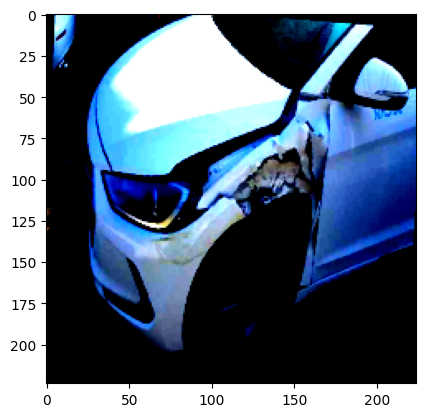

In [14]:
plt.imshow(images[2].permute(1, 2, 0))
plt.show()

### Model 1:CNN

In [15]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)

        )
        
    def forward(self, x):
        x = self.network(x)
        return x



In [16]:
model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)


In [17]:
def train_model(model, criterion, optimizer, epochs = 5):
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            if (batch_num + 1) % 10 == 0:
                print(f'Batch: {batch_num + 1}, Epoch: {epoch+1}, Loss: {loss.item():0.2f}')

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f'Epoch [{epoch+1} / {epochs}], Avg Loss: {epoch_loss:.4f}')


        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

            print(f'*** Validation Accuracy: {100 * correct / total:.2f}% ***')

    end = time.time()
    print(f'Execution time: {end - start} seconds')
    return all_labels, all_predictions

In [ ]:
all_labels, all_predictions = train_model(model, criterion, optimizer, epochs = 5)

Batch: 10, Epoch: 1, Loss: 1.77
Batch: 20, Epoch: 1, Loss: 1.56
Batch: 30, Epoch: 1, Loss: 1.49
Batch: 40, Epoch: 1, Loss: 1.69
Batch: 50, Epoch: 1, Loss: 1.50
Epoch [1 / 5], Avg Loss: 0.0543
*** Validation Accuracy: 43.48% ***
Batch: 10, Epoch: 2, Loss: 1.28
Batch: 20, Epoch: 2, Loss: 1.02


### Model 2: CNN with Regularization

In [ ]:
class CarClassifierCNNWithRegularization(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)

        )
        
    def forward(self, x):
        x = self.network(x)
        return x



In [20]:
model = CarClassifierCNNWithRegularization(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001, weight_decay = 1e-4)

train_model(model, criterion, optimizer, epochs = 10)

Epoch [4 / 10], Avg Loss: 0.0383
*** Validation Accuracy: 50.26% ***
Batch: 10, Epoch: 5, Loss: 1.23
Batch: 20, Epoch: 5, Loss: 1.34
Batch: 30, Epoch: 5, Loss: 1.27
Batch: 40, Epoch: 5, Loss: 1.09
Batch: 50, Epoch: 5, Loss: 1.28
Epoch [5 / 10], Avg Loss: 0.0373
*** Validation Accuracy: 53.04% ***
Batch: 10, Epoch: 6, Loss: 1.09
Batch: 20, Epoch: 6, Loss: 1.09
Batch: 30, Epoch: 6, Loss: 1.11
Batch: 40, Epoch: 6, Loss: 1.34
Batch: 50, Epoch: 6, Loss: 1.08
Epoch [6 / 10], Avg Loss: 0.0364
*** Validation Accuracy: 52.17% ***
Batch: 10, Epoch: 7, Loss: 1.05
Batch: 20, Epoch: 7, Loss: 1.29
Batch: 30, Epoch: 7, Loss: 0.99
Batch: 40, Epoch: 7, Loss: 1.10
Batch: 50, Epoch: 7, Loss: 1.56
Epoch [7 / 10], Avg Loss: 0.0348
*** Validation Accuracy: 52.87% ***
Batch: 10, Epoch: 8, Loss: 1.08
Batch: 20, Epoch: 8, Loss: 1.06
Batch: 30, Epoch: 8, Loss: 1.10
Batch: 40, Epoch: 8, Loss: 0.92
Batch: 50, Epoch: 8, Loss: 1.05
Epoch [8 / 10], Avg Loss: 0.0345
*** Validation Accuracy: 52.35% ***
Batch: 10, Epoc

([np.int64(2),
  np.int64(0),
  np.int64(3),
  np.int64(2),
  np.int64(5),
  np.int64(0),
  np.int64(3),
  np.int64(3),
  np.int64(2),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(3),
  np.int64(3),
  np.int64(5),
  np.int64(3),
  np.int64(3),
  np.int64(2),
  np.int64(5),
  np.int64(4),
  np.int64(4),
  np.int64(3),
  np.int64(4),
  np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(3),
  np.int64(3),
  np.int64(0),
  np.int64(1),
  np.int64(4),
  np.int64(2),
  np.int64(2),
  np.int64(4),
  np.int64(0),
  np.int64(4),
  np.int64(1),
  np.int64(1),
  np.int64(3),
  np.int64(1),
  np.int64(3),
  np.int64(1),
  np.int64(0),
  np.int64(2),
  np.int64(1),
  np.int64(1),
  np.int64(3),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(0),
  np.int64(2),
  np.int64(2),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(3),
  np.int64(0),
  np.int64(5),
  np.int64(5),
  np.int64(0),
  np.int64(2),
  np.int64

### Model 3: Transfer Learning with EfficientNet

In [21]:
model = models.efficientnet_b0(weights='DEFAULT')
model.classifier[1].in_features

1280

In [26]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights='DEFAULT')

        for param in self.model.parameters():
            param.requires_grad = False

        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [27]:
model = CarClassifierEfficientNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

train_model(model, criterion, optimizer, epochs = 10)

Batch: 10, Epoch: 1, Loss: 1.74
Batch: 20, Epoch: 1, Loss: 1.55
Batch: 30, Epoch: 1, Loss: 1.38
Batch: 40, Epoch: 1, Loss: 1.48
Batch: 50, Epoch: 1, Loss: 1.38
Epoch [1 / 10], Avg Loss: 0.0468
*** Validation Accuracy: 57.22% ***
Batch: 10, Epoch: 2, Loss: 1.11
Batch: 20, Epoch: 2, Loss: 1.10
Batch: 30, Epoch: 2, Loss: 1.13
Batch: 40, Epoch: 2, Loss: 1.12
Batch: 50, Epoch: 2, Loss: 1.14
Epoch [2 / 10], Avg Loss: 0.0358
*** Validation Accuracy: 62.09% ***
Batch: 10, Epoch: 3, Loss: 1.11
Batch: 20, Epoch: 3, Loss: 0.92
Batch: 30, Epoch: 3, Loss: 1.21
Batch: 40, Epoch: 3, Loss: 1.02
Batch: 50, Epoch: 3, Loss: 0.87
Epoch [3 / 10], Avg Loss: 0.0320
*** Validation Accuracy: 65.74% ***
Batch: 10, Epoch: 4, Loss: 0.92
Batch: 20, Epoch: 4, Loss: 0.99
Batch: 30, Epoch: 4, Loss: 1.03
Batch: 40, Epoch: 4, Loss: 0.98
Batch: 50, Epoch: 4, Loss: 0.92
Epoch [4 / 10], Avg Loss: 0.0298
*** Validation Accuracy: 65.91% ***
Batch: 10, Epoch: 5, Loss: 0.89
Batch: 20, Epoch: 5, Loss: 1.00
Batch: 30, Epoch: 5,

([np.int64(3),
  np.int64(2),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(5),
  np.int64(3),
  np.int64(0),
  np.int64(3),
  np.int64(1),
  np.int64(5),
  np.int64(4),
  np.int64(5),
  np.int64(0),
  np.int64(4),
  np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(0),
  np.int64(3),
  np.int64(3),
  np.int64(2),
  np.int64(1),
  np.int64(4),
  np.int64(3),
  np.int64(1),
  np.int64(2),
  np.int64(1),
  np.int64(5),
  np.int64(3),
  np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(4),
  np.int64(5),
  np.int64(2),
  np.int64(5),
  np.int64(5),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(1),
  np.int64(5),
  np.int64(3),
  np.int64(2),
  np.int64(2),
  np.int64(3),
  np.int64(1),
  np.int64(4),
  np.int64(3),
  np.int64(4),
  np.int64(5),
  np.int64(5),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(2),
  np.int64(5),
  np.int64

### Model 4: Transfer Learning with ResNet

In [32]:
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate = 0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')

        for param in self.model.parameters():
            param.requires_grad = False

        for param in self.model.layer4.parameters():
            param.requires_grad = True

        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [31]:

print(device)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
print(next(model.parameters()).device)

cuda
NVIDIA GeForce MX550
cuda:0


In [33]:
model = CarClassifierResNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

labels, predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 1.02
Batch: 20, Epoch: 1, Loss: 0.92
Batch: 30, Epoch: 1, Loss: 0.77
Batch: 40, Epoch: 1, Loss: 0.87
Batch: 50, Epoch: 1, Loss: 0.42
Epoch [1 / 10], Avg Loss: 0.0269
*** Validation Accuracy: 73.74% ***
Batch: 10, Epoch: 2, Loss: 0.50
Batch: 20, Epoch: 2, Loss: 0.47
Batch: 30, Epoch: 2, Loss: 0.77
Batch: 40, Epoch: 2, Loss: 0.36
Batch: 50, Epoch: 2, Loss: 0.44
Epoch [2 / 10], Avg Loss: 0.0155
*** Validation Accuracy: 75.65% ***
Batch: 10, Epoch: 3, Loss: 0.28
Batch: 20, Epoch: 3, Loss: 0.35
Batch: 30, Epoch: 3, Loss: 0.41
Batch: 40, Epoch: 3, Loss: 0.34
Batch: 50, Epoch: 3, Loss: 0.22
Epoch [3 / 10], Avg Loss: 0.0107
*** Validation Accuracy: 76.00% ***
Batch: 10, Epoch: 4, Loss: 0.32
Batch: 20, Epoch: 4, Loss: 0.18
Batch: 30, Epoch: 4, Loss: 0.12
Batch: 40, Epoch: 4, Loss: 0.12
Batch: 50, Epoch: 4, Loss: 0.40
Epoch [4 / 10], Avg Loss: 0.0074
*** Validation Accuracy: 75.13% ***
Batch: 10, Epoch: 5, Loss: 0.24
Batch: 20, Epoch: 5, Loss: 0.08
Batch: 30, Epoch: 5,

In [34]:
model = CarClassifierResNet(num_classes=num_classes, dropout_rate=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.005)

labels, predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 0.89
Batch: 20, Epoch: 1, Loss: 0.73
Batch: 30, Epoch: 1, Loss: 0.55
Batch: 40, Epoch: 1, Loss: 0.53
Batch: 50, Epoch: 1, Loss: 0.55
Epoch [1 / 10], Avg Loss: 0.0271
*** Validation Accuracy: 73.22% ***
Batch: 10, Epoch: 2, Loss: 0.34
Batch: 20, Epoch: 2, Loss: 0.66
Batch: 30, Epoch: 2, Loss: 0.44
Batch: 40, Epoch: 2, Loss: 0.53
Batch: 50, Epoch: 2, Loss: 0.28
Epoch [2 / 10], Avg Loss: 0.0148
*** Validation Accuracy: 75.48% ***
Batch: 10, Epoch: 3, Loss: 0.37
Batch: 20, Epoch: 3, Loss: 0.33
Batch: 30, Epoch: 3, Loss: 0.44
Batch: 40, Epoch: 3, Loss: 0.24
Batch: 50, Epoch: 3, Loss: 0.32
Epoch [3 / 10], Avg Loss: 0.0107
*** Validation Accuracy: 76.70% ***
Batch: 10, Epoch: 4, Loss: 0.11
Batch: 20, Epoch: 4, Loss: 0.08
Batch: 30, Epoch: 4, Loss: 0.25
Batch: 40, Epoch: 4, Loss: 0.22
Batch: 50, Epoch: 4, Loss: 0.30
Epoch [4 / 10], Avg Loss: 0.0073
*** Validation Accuracy: 75.83% ***
Batch: 10, Epoch: 5, Loss: 0.41
Batch: 20, Epoch: 5, Loss: 0.10
Batch: 30, Epoch: 5,

### Model Evaluation using Confusion Matrix and Classification Report

In [35]:
from sklearn.metrics import classification_report

report = classification_report(labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.84      0.82      0.83       118
           1       0.71      0.71      0.71        99
           2       0.86      0.91      0.88       131
           3       0.82      0.77      0.79        75
           4       0.74      0.74      0.74        76
           5       0.82      0.82      0.82        76

    accuracy                           0.80       575
   macro avg       0.80      0.79      0.80       575
weighted avg       0.80      0.80      0.80       575



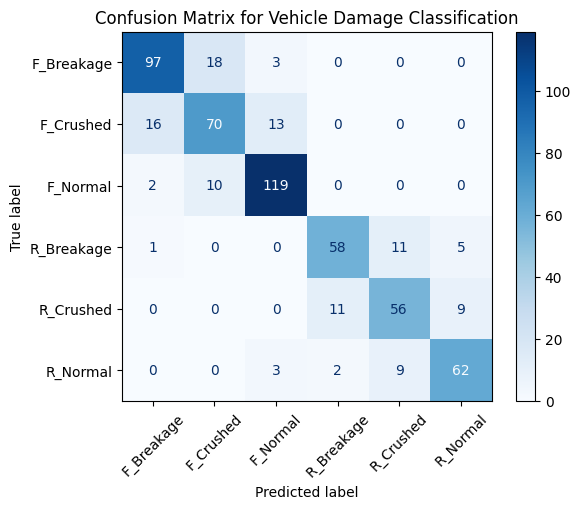

In [36]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

### Save the Model

In [37]:
torch.save(model.state_dict(), 'saved_model.pth')